In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.src.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1777519856.790928   21565 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Data paths and parameters
train_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
img_size = (224, 224)
batch_size = 32
project_root = Path('/home/groggy/projects/Image-Classification-Explainability')

## Three-Way Data Split: Train / Validation / Test

**Split strategy:**
- Training: 60% (5400 images)
- Validation: 20% (1800 images) - used for hyperparameter tuning and early stopping
- Test: 20% (1800 images) - held out for final evaluation

This allows us to compare validation accuracy (used during training) with test accuracy (unseen during training).

In [3]:
# Create three separate data generators
# Training set: 60%
train_datagen = ImageDataGenerator(validation_split=0.4)  # 60% train, 40% other

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

# From the remaining 40%, split equally into validation (20%) and test (20%)
val_test_datagen = ImageDataGenerator(validation_split=0.5)  # Split the 40% in half

val_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',  # First half of the 40% = 20% validation
    shuffle=False,
    seed=SEED + 1  # Different seed for different split
)

test_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',  # Second half of the 40% = 20% test
    shuffle=False,
    seed=SEED + 1
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"\nData split:")
print(f"  Training samples: {train_generator.samples} ({train_generator.samples/9000*100:.1f}%)")
print(f"  Validation samples: {val_generator.samples} ({val_generator.samples/9000*100:.1f}%)")
print(f"  Test samples: {test_generator.samples} ({test_generator.samples/9000*100:.1f}%)")
print(f"  Total: {train_generator.samples + val_generator.samples + test_generator.samples}")

Found 5400 images belonging to 9 classes.
Found 4500 images belonging to 9 classes.
Found 4500 images belonging to 9 classes.
Number of classes: 9
Class names: ['Black Sea Sprat', 'Gilt-Head Bream', 'Hourse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']

Data split:
  Training samples: 5400 (60.0%)
  Validation samples: 4500 (50.0%)
  Test samples: 4500 (50.0%)
  Total: 14400


## Architecture - MobileNetV3Large Improved

**Architecture:**
- Base: MobileNetV3Large (frozen)
- GlobalAveragePooling2D
- Dense(512, relu) → Dropout(0.5)
- Dense(256, relu) → Dropout(0.3)
- Dense(9, softmax)

In [4]:
# Build base model
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep frozen

print(f"Base model output shape: {base_model.output_shape}")
print(f"Base model has {len(base_model.layers)} layers")

W0000 00:00:1777519863.005918   21565 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Base model output shape: (None, 7, 7, 960)
Base model has 187 layers


In [5]:
# Build classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', name='dense_512')(x)
x = Dropout(0.5, name='dropout_1')(x)
x = Dense(256, activation='relu', name='dense_256')(x)
x = Dropout(0.3, name='dropout_2')(x)
predictions = Dense(num_classes, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=predictions)

print(f"\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")


Total parameters: 3,622,025
Trainable parameters: 625,673
Non-trainable parameters: 2,996,352


In [6]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Create ModelCheckpoint callback to save best model based on val_loss
checkpoint_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Improved_TrainValTest_best.keras'
checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Train model with validation set
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9876 - loss: 0.0335
Epoch 1: val_loss improved from None to 0.00401, saving model to /home/groggy/projects/Image-Classification-Explainability/ML/Models/MobileNetV3Large_Improved_TrainValTest_best.keras

Epoch 1: finished saving model to /home/groggy/projects/Image-Classification-Explainability/ML/Models/MobileNetV3Large_Improved_TrainValTest_best.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 134s 793ms/step - accuracy: 0.9856 - loss: 0.0404 - val_accuracy: 0.9987 - val_loss: 0.0040
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9961 - loss: 0.0125
Epoch 2: val_loss improved from 0.00401 to 0.00270, saving model to /home/groggy/projects/Image-Classification-Explainability/ML/Models/MobileNetV3Large_Improved_TrainValTest_best.keras

Epoch 2: finished saving model to /home/groggy/projects/Image-Classification-Explainability/ML/Models/MobileNetV3Large_Improved_TrainValTest_best.keras
169/169 ━━━━━━━━━━━━━━━━━━━━

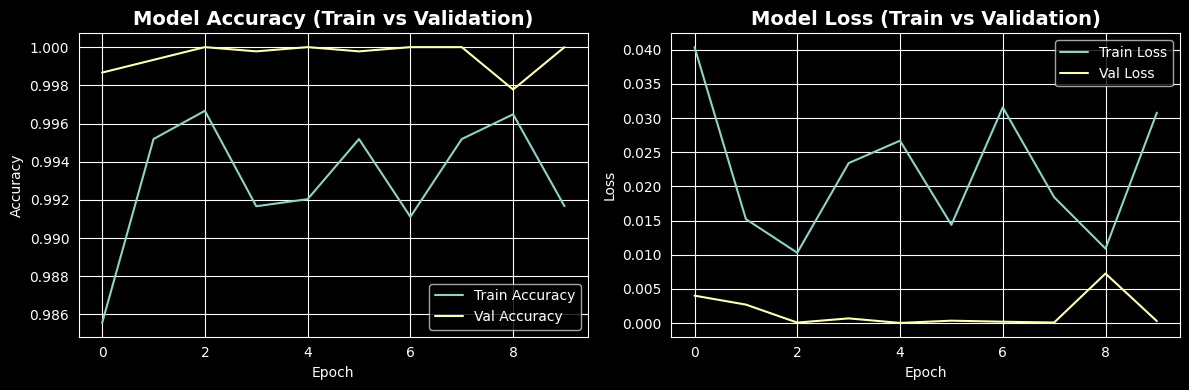

In [10]:
# Visualize training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (Train vs Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Train vs Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Validation vs Test Accuracy Comparison

Now we compare the validation accuracy (used during training) with the test accuracy (completely unseen).

In [11]:
# Evaluate on validation set
print("Evaluating on VALIDATION set...")
val_loss, val_accuracy = model.evaluate(val_generator, verbose=1)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

print("\n" + "="*70)

# Evaluate on test set
print("Evaluating on TEST set...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "="*70)
print("VALIDATION vs TEST COMPARISON")
print("="*70)
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Test Accuracy:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Difference:          {abs(val_accuracy - test_accuracy):.4f} ({abs(val_accuracy - test_accuracy)*100:.2f}%)")
if test_accuracy >= val_accuracy:
    print("\n✓ Test accuracy >= Validation accuracy (no overfitting detected)")
else:
    print(f"\n⚠ Test accuracy is {(val_accuracy - test_accuracy)*100:.2f}% lower (possible overfitting)")
print("="*70)

Evaluating on VALIDATION set...
141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 381ms/step - accuracy: 1.0000 - loss: 2.7976e-04
Validation Loss: 0.0003
Validation Accuracy: 1.0000 (100.00%)

Evaluating on TEST set...
141/141 ━━━━━━━━━━━━━━━━━━━━ 60s 424ms/step - accuracy: 0.9802 - loss: 0.0771
Test Loss: 0.0771
Test Accuracy: 0.9802 (98.02%)

VALIDATION vs TEST COMPARISON
Validation Accuracy: 1.0000 (100.00%)
Test Accuracy:       0.9802 (98.02%)
Difference:          0.0198 (1.98%)

⚠ Test accuracy is 1.98% lower (possible overfitting)


In [12]:
# Generate predictions for both validation and test sets
print("Generating predictions for VALIDATION set...")
val_generator.reset()
val_predictions = model.predict(val_generator, verbose=1)
val_predicted_classes = np.argmax(val_predictions, axis=1)
val_true_classes = val_generator.classes

print("\nGenerating predictions for TEST set...")
test_generator.reset()
test_predictions = model.predict(test_generator, verbose=1)
test_predicted_classes = np.argmax(test_predictions, axis=1)
test_true_classes = test_generator.classes

print(f"\nValidation predictions: {len(val_predicted_classes)}")
print(f"Test predictions: {len(test_predicted_classes)}")

Generating predictions for VALIDATION set...
141/141 ━━━━━━━━━━━━━━━━━━━━ 57s 395ms/step

Generating predictions for TEST set...
141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 381ms/step

Validation predictions: 4500
Test predictions: 4500


## Detailed Analysis - Validation Set

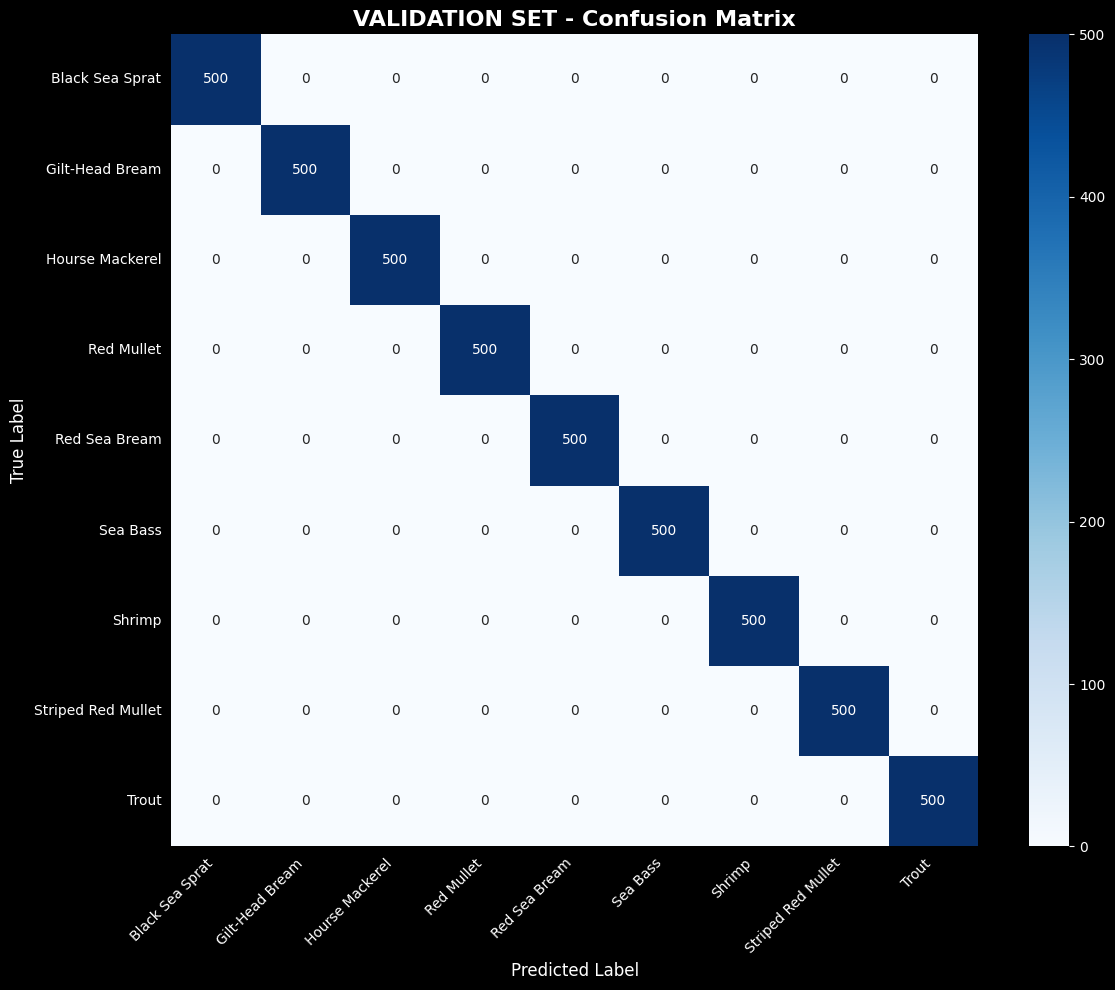

In [13]:
# Validation: Confusion Matrix
val_cm = confusion_matrix(val_true_classes, val_predicted_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('VALIDATION SET - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

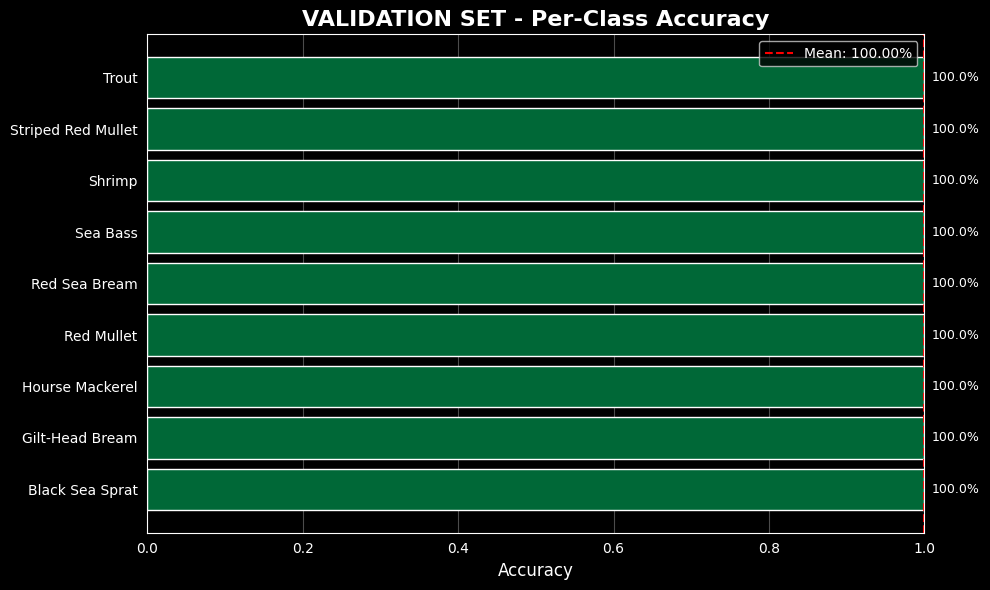


VALIDATION SET - Class Accuracy Summary:
             Class  Accuracy
   Black Sea Sprat       1.0
   Gilt-Head Bream       1.0
   Hourse Mackerel       1.0
        Red Mullet       1.0
     Red Sea Bream       1.0
          Sea Bass       1.0
            Shrimp       1.0
Striped Red Mullet       1.0
             Trout       1.0


In [14]:
# Validation: Per-class accuracy
val_cm_normalized = val_cm.astype('float') / val_cm.sum(axis=1)[:, np.newaxis]
val_class_accuracies = val_cm_normalized.diagonal()
val_class_acc_df = pd.DataFrame({
    'Class': class_names,
    'Accuracy': val_class_accuracies
}).sort_values('Accuracy', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(val_class_acc_df['Accuracy'])
bars = plt.barh(val_class_acc_df['Class'], val_class_acc_df['Accuracy'], color=colors)
plt.xlabel('Accuracy', fontsize=12)
plt.title('VALIDATION SET - Per-Class Accuracy', fontsize=16, fontweight='bold')
plt.xlim(0, 1)
plt.axvline(x=val_class_acc_df['Accuracy'].mean(), color='red', linestyle='--',
            label=f'Mean: {val_class_acc_df["Accuracy"].mean():.2%}')
plt.legend()
plt.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(val_class_acc_df.iterrows()):
    plt.text(row['Accuracy'] + 0.01, i, f"{row['Accuracy']:.1%}",
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nVALIDATION SET - Class Accuracy Summary:")
print(val_class_acc_df.sort_values('Accuracy', ascending=False).to_string(index=False))

## Detailed Analysis - Test Set

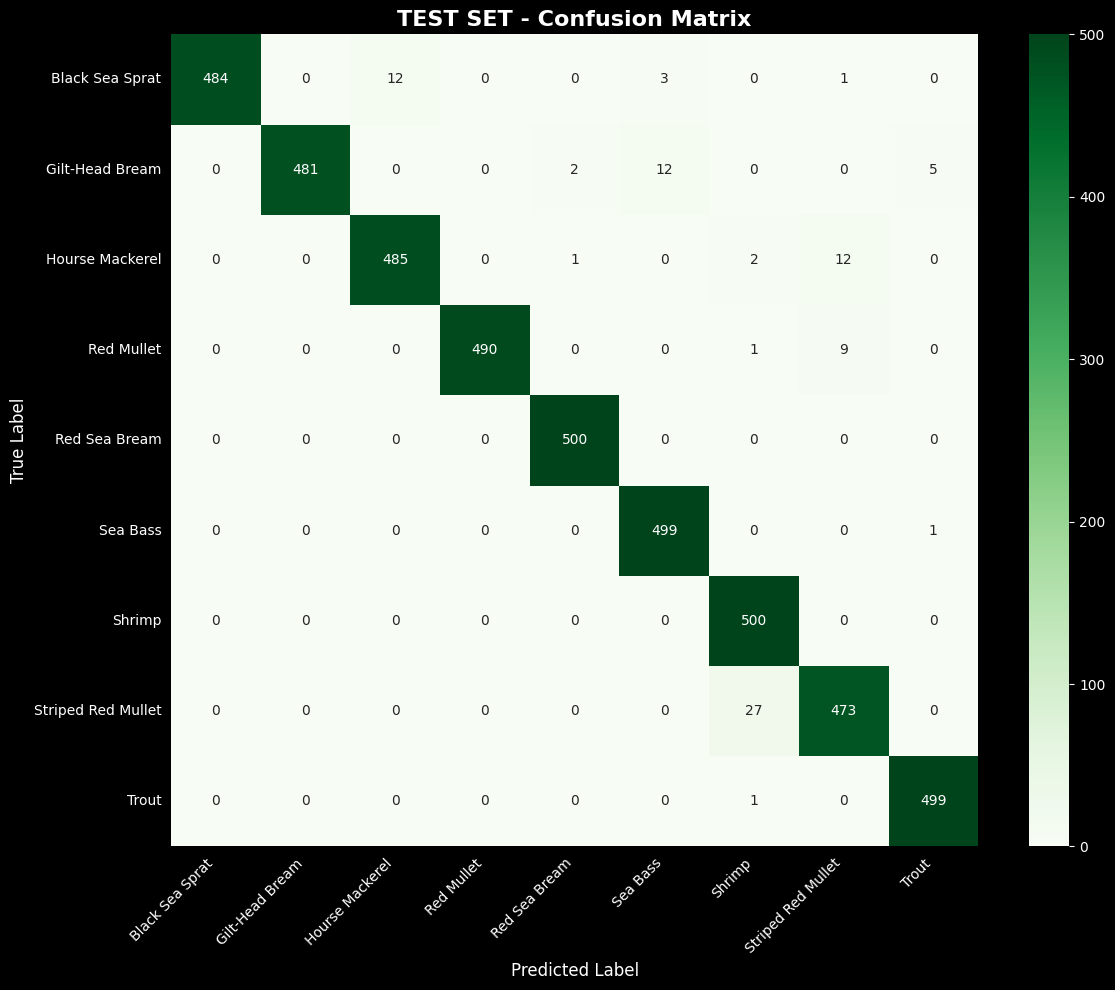

In [15]:
# Test: Confusion Matrix
test_cm = confusion_matrix(test_true_classes, test_predicted_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('TEST SET - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

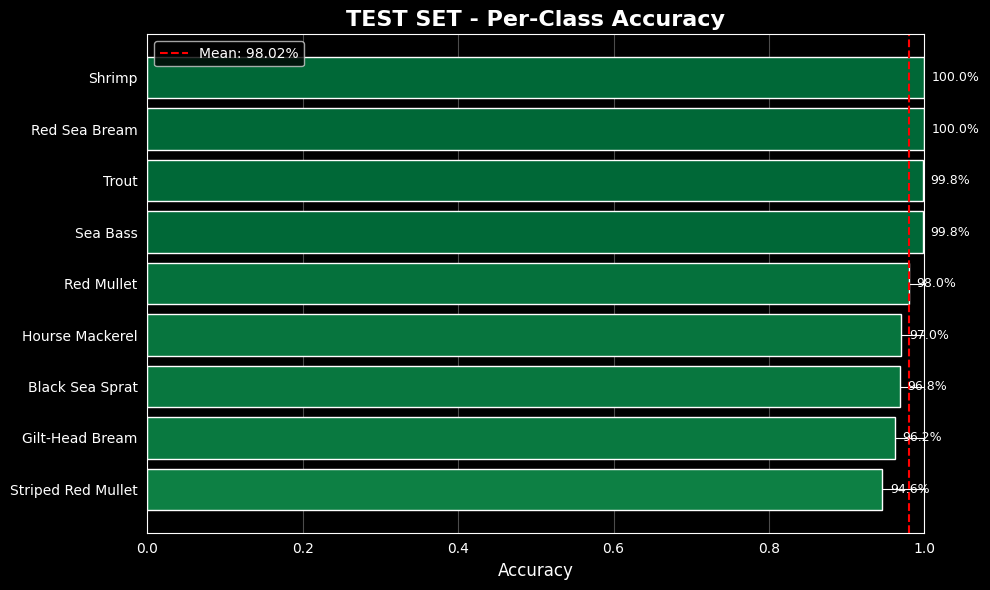


TEST SET - Class Accuracy Summary:
             Class  Accuracy
     Red Sea Bream     1.000
            Shrimp     1.000
          Sea Bass     0.998
             Trout     0.998
        Red Mullet     0.980
   Hourse Mackerel     0.970
   Black Sea Sprat     0.968
   Gilt-Head Bream     0.962
Striped Red Mullet     0.946


In [16]:
# Test: Per-class accuracy
test_cm_normalized = test_cm.astype('float') / test_cm.sum(axis=1)[:, np.newaxis]
test_class_accuracies = test_cm_normalized.diagonal()
test_class_acc_df = pd.DataFrame({
    'Class': class_names,
    'Accuracy': test_class_accuracies
}).sort_values('Accuracy', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(test_class_acc_df['Accuracy'])
bars = plt.barh(test_class_acc_df['Class'], test_class_acc_df['Accuracy'], color=colors)
plt.xlabel('Accuracy', fontsize=12)
plt.title('TEST SET - Per-Class Accuracy', fontsize=16, fontweight='bold')
plt.xlim(0, 1)
plt.axvline(x=test_class_acc_df['Accuracy'].mean(), color='red', linestyle='--',
            label=f'Mean: {test_class_acc_df["Accuracy"].mean():.2%}')
plt.legend()
plt.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(test_class_acc_df.iterrows()):
    plt.text(row['Accuracy'] + 0.01, i, f"{row['Accuracy']:.1%}",
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTEST SET - Class Accuracy Summary:")
print(test_class_acc_df.sort_values('Accuracy', ascending=False).to_string(index=False))

## Side-by-Side Comparison: Validation vs Test

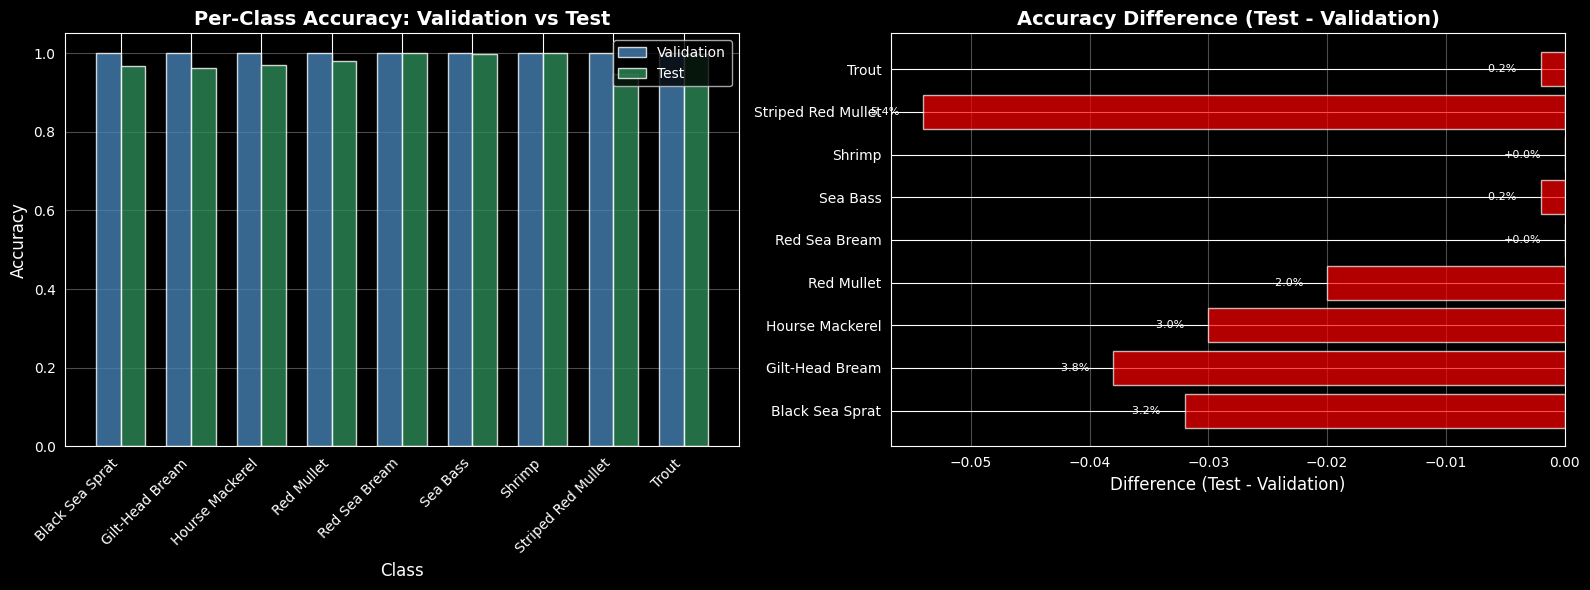


Per-Class Accuracy Comparison:
             Class  Validation  Test  Difference
   Black Sea Sprat         1.0 0.968      -0.032
   Gilt-Head Bream         1.0 0.962      -0.038
   Hourse Mackerel         1.0 0.970      -0.030
        Red Mullet         1.0 0.980      -0.020
     Red Sea Bream         1.0 1.000       0.000
          Sea Bass         1.0 0.998      -0.002
            Shrimp         1.0 1.000       0.000
Striped Red Mullet         1.0 0.946      -0.054
             Trout         1.0 0.998      -0.002


In [17]:
# Side-by-side per-class accuracy comparison
comparison_df = pd.DataFrame({
    'Class': class_names,
    'Validation': val_class_accuracies,
    'Test': test_class_accuracies,
    'Difference': test_class_accuracies - val_class_accuracies
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: grouped bar chart
x = np.arange(len(class_names))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Validation'], width, label='Validation', alpha=0.8, color='steelblue')
axes[0].bar(x + width/2, comparison_df['Test'], width, label='Test', alpha=0.8, color='seagreen')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Per-Class Accuracy: Validation vs Test', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Right plot: difference
colors_diff = ['green' if d >= 0 else 'red' for d in comparison_df['Difference']]
axes[1].barh(comparison_df['Class'], comparison_df['Difference'], color=colors_diff, alpha=0.7)
axes[1].set_xlabel('Difference (Test - Validation)', fontsize=12)
axes[1].set_title('Accuracy Difference (Test - Validation)', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(comparison_df.iterrows()):
    val = row['Difference']
    axes[1].text(val + 0.002 if val > 0 else val - 0.002, i, 
                 f"{val:+.1%}", va='center', ha='left' if val > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print("\nPer-Class Accuracy Comparison:")
print(comparison_df.to_string(index=False))

In [18]:
# Overall metrics comparison
val_correct = np.sum(val_predicted_classes == val_true_classes)
test_correct = np.sum(test_predicted_classes == test_true_classes)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Loss', 'Correct Predictions', 'Incorrect Predictions', 'Total Samples'],
    'Validation': [
        f"{val_accuracy:.4f} ({val_accuracy*100:.2f}%)",
        f"{val_loss:.4f}",
        val_correct,
        len(val_true_classes) - val_correct,
        len(val_true_classes)
    ],
    'Test': [
        f"{test_accuracy:.4f} ({test_accuracy*100:.2f}%)",
        f"{test_loss:.4f}",
        test_correct,
        len(test_true_classes) - test_correct,
        len(test_true_classes)
    ]
})

print("\n" + "="*70)
print("OVERALL METRICS COMPARISON")
print("="*70)
print(metrics_comparison.to_string(index=False))
print("="*70)


OVERALL METRICS COMPARISON
               Metric       Validation            Test
             Accuracy 1.0000 (100.00%) 0.9802 (98.02%)
                 Loss           0.0003          0.0771
  Correct Predictions             4500            4411
Incorrect Predictions                0              89
        Total Samples             4500            4500


In [19]:
# Final comprehensive summary
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("\n" + "="*70)
print("FINAL MODEL SUMMARY - TRAIN/VAL/TEST SPLIT")
print("="*70)

print("\nMODEL ARCHITECTURE:")
print(f"  Total Parameters: {total_params:,}")
print(f"  Trainable Parameters: {trainable_params:,}")
print(f"  Non-trainable Parameters: {non_trainable_params:,}")

print("\nDATA SPLIT:")
print(f"  Training: {train_generator.samples} samples ({train_generator.samples/9000*100:.1f}%)")
print(f"  Validation: {val_generator.samples} samples ({val_generator.samples/9000*100:.1f}%)")
print(f"  Test: {test_generator.samples} samples ({test_generator.samples/9000*100:.1f}%)")

print("\nVALIDATION PERFORMANCE:")
print(f"  Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"  Loss: {val_loss:.4f}")
print(f"  Correct: {val_correct}/{len(val_true_classes)}")

print("\nTEST PERFORMANCE:")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Loss: {test_loss:.4f}")
print(f"  Correct: {test_correct}/{len(test_true_classes)}")

print("\nCOMPARISON:")
print(f"  Accuracy Difference: {abs(val_accuracy - test_accuracy):.4f} ({abs(val_accuracy - test_accuracy)*100:.2f}%)")
print(f"  Loss Difference: {abs(val_loss - test_loss):.4f}")

if abs(val_accuracy - test_accuracy) < 0.02:
    print("\n  ✓ Model generalizes well (< 2% difference)")
elif abs(val_accuracy - test_accuracy) < 0.05:
    print("\n  ⚠ Moderate generalization gap (2-5% difference)")
else:
    print("\n  ⚠ Significant generalization gap (> 5% difference)")

print("\nBEST PERFORMING CLASSES:")
print(f"  Validation: {val_class_acc_df.iloc[-1]['Class']} ({val_class_acc_df.iloc[-1]['Accuracy']:.2%})")
print(f"  Test: {test_class_acc_df.iloc[-1]['Class']} ({test_class_acc_df.iloc[-1]['Accuracy']:.2%})")

print("\nWORST PERFORMING CLASSES:")
print(f"  Validation: {val_class_acc_df.iloc[0]['Class']} ({val_class_acc_df.iloc[0]['Accuracy']:.2%})")
print(f"  Test: {test_class_acc_df.iloc[0]['Class']} ({test_class_acc_df.iloc[0]['Accuracy']:.2%})")

print("="*70)


FINAL MODEL SUMMARY - TRAIN/VAL/TEST SPLIT

MODEL ARCHITECTURE:
  Total Parameters: 3,622,025
  Trainable Parameters: 625,673
  Non-trainable Parameters: 2,996,352

DATA SPLIT:
  Training: 5400 samples (60.0%)
  Validation: 4500 samples (50.0%)
  Test: 4500 samples (50.0%)

VALIDATION PERFORMANCE:
  Accuracy: 1.0000 (100.00%)
  Loss: 0.0003
  Correct: 4500/4500

TEST PERFORMANCE:
  Accuracy: 0.9802 (98.02%)
  Loss: 0.0771
  Correct: 4411/4500

COMPARISON:
  Accuracy Difference: 0.0198 (1.98%)
  Loss Difference: 0.0768

  ✓ Model generalizes well (< 2% difference)

BEST PERFORMING CLASSES:
  Validation: Trout (100.00%)
  Test: Shrimp (100.00%)

WORST PERFORMING CLASSES:
  Validation: Black Sea Sprat (100.00%)
  Test: Striped Red Mullet (94.60%)


In [20]:
# Save final model
save_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Improved_TrainValTest.keras'
model.save(save_path)
print(f'✓ Model saved to: {save_path}')

✓ Model saved to: /home/groggy/projects/Image-Classification-Explainability/ML/Models/MobileNetV3Large_Improved_TrainValTest.keras
